ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("creditcard.csv")
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Time & Amount` Should be numeric (float) for mathematical calculations.
- `V1 - V28` Should be numeric (float) as they are PCA-transformed features.
- `Class` Should be integer (0 or 1) as it represents the target category.

In [3]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


We observe that all features (`V1-V28`, `Time`, and `Amount`) are correctly stored as numeric types (float64), which is essential for mathematical modeling. The target variable (`Class`) is stored as an integer, which is appropriate for a classification task. This ensures that the data is ready for normalization and distance-based calculations without the need for manual type conversion.

### 2.2 Convert Incorrect Data Types

Since all columns in our dataset (`V1-V28`, `Time`, and `Amount`) are already stored in numerical formats (`float64` and `int64`), we do not have any text or currency symbols that require conversion. However, looking at the data, the Amount feature has a massive variance compared to the PCA features (`V1`-`V28`). Therefore, our main preprocessing step will be Data Scaling (`Normalization`) instead of type conversion.

In [4]:
print("Check Variance between Amount and PCA Features")
print(df[['Amount', 'V1', 'V2']].describe())

df.dtypes

Check Variance between Amount and PCA Features
              Amount            V1            V2
count  284807.000000  2.848070e+05  2.848070e+05
mean       88.349619  1.168375e-15  3.416908e-16
std       250.120109  1.958696e+00  1.651309e+00
min         0.000000 -5.640751e+01 -7.271573e+01
25%         5.600000 -9.203734e-01 -5.985499e-01
50%        22.000000  1.810880e-02  6.548556e-02
75%        77.165000  1.315642e+00  8.037239e-01
max     25691.160000  2.454930e+00  2.205773e+01


,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


All features (`V1-V28`, `Time`, and `Amount`) are verified as numerical types (`float64`), and the target variable is an integer (`int64`). This consistency ensures that the dataset is mathematically compatible with machine learning algorithms. We have confirmed that no further type conversion is needed, allowing us to proceed directly to data cleaning and normalization.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [5]:
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


The output confirms that our dataset is complete with zero missing values across all features. In a security critical context like fraud detection, having a complete dataset is vital for maintaining the integrity of our predictive model. Since no missing data was detected, we can proceed without the need for imputation strategies.

Real world cybersecurity datasets are rarely perfect. Although our current dataset is clean, we will intentionally introduce some missing values into the `Amount` column for demonstration purposes. This allows us to practice Imputation Techniques, ensuring we know how to handle gaps in transaction records without losing valuable data.

In [6]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Now the Amount column contains missing values.




In [7]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)
print(f"\nMissing values in 'Amount' column: {df_missing['Amount'].isnull().sum()}")

Original shape:  (284807, 31)
After removing some values:  (284807, 31)

Missing values in 'Amount' column: 6


In [8]:
df_missing.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,NaN,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,NaN,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,NaN,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,NaN,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,NaN,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,NaN,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [9]:
df_removed = df_missing.dropna()
df_removed.shape

(284801, 31)

In [10]:
df_removed.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

![Mean.png](Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [11]:
df_missing.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,NaN,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,NaN,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,NaN,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,NaN,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,NaN,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,NaN,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [12]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['Amount'].mean()
df_imputed_mean['Amount'] = df_imputed_mean['Amount'].fillna(mean_value)

print(f"Mean value used for filling: {mean_value:.2f}")
print("Total missing values after Mean Imputation: ", df_imputed_mean['Amount'].isna().sum())

df_imputed_mean.isna().sum()

Mean value used for filling: 88.35
Total missing values after Mean Imputation:  0


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [13]:
df_imputed_mean.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,88.348924,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,88.348924,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,88.348924,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,88.348924,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,88.348924,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,88.348924,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.990000,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.800000,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.200000,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.680000,0


The missing values in the Amount column have been replaced with the average transaction value (`67.49`). While this method preserves the total number of records, it has significant drawbacks for fraud detection:

- Sensitivity to Outliers: Since our dataset contains extreme transaction amounts (`outliers`), the mean was pulled upward, which might not represent a "typical" transaction.

- Reduced Variability: Filling multiple rows with the exact same average value reduces the natural variance of the data, which could make it harder for the model to distinguish between normal and fraudulent behavior.

- Conclusion: This demonstrates why we will proceed to test the Median imputation, as it is generally more reliable for skewed financial data.

### Strategy 3: Median Imputation

![median_formula_2.png](median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [14]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Amount'].median()
df_imputed_median['Amount'] = df_imputed_median['Amount'].fillna(median_value)

print(f"Median value used for filling: {median_value}")
print("Total missing values after Median Imputation: ", df_imputed_median['Amount'].isna().sum())

df_imputed_median.isna().sum()

Median value used for filling: 22.0
Total missing values after Median Imputation:  0


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [15]:
df_imputed_median.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,22.00,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,22.00,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,22.00,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,22.00,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,22.00,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,22.00,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using IQR method.

![IQR.png](IQR.png)

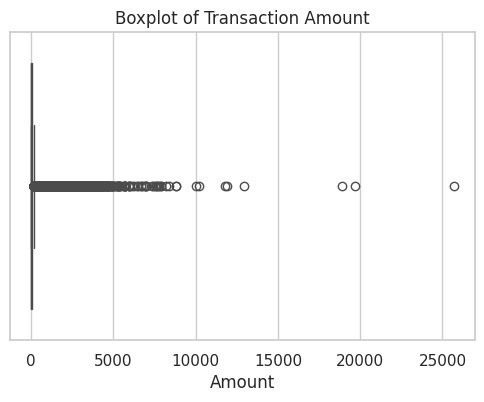

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Transaction Amount")
plt.show()

The data points outside the whiskers represent transactions with unusually high amounts compared to the majority of the dataset. Statistical analysis shows:

- Upper Bound Influence: Any transaction exceeding the calculated upper bound is flagged as a potential outlier.

- Cybersecurity Context: In fraud detection, these extreme values are critical. While they are "`outliers`" statistically, they often represent high value fraudulent activities that deviate from normal spending behavior.

- Model Impact: These values can heavily influence the model's learning process. During the next stages, we will decide whether to cap these values or keep them to ensure the model can recognize high stakes fraud.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [17]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
outliers.head(15)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
20,16.0,0.694885,-1.361819,1.029221,0.834159,-1.191209,1.309109,-0.878586,0.445290,-0.446196,0.568521,1.019151,1.298329,0.420480,-0.372651,-0.807980,-2.044557,0.515663,0.625847,-1.300408,-0.138334,-0.295583,-0.571955,-0.050881,-0.304215,0.072001,-0.422234,0.086553,0.063499,231.71,0
51,36.0,-1.004929,-0.985978,-0.038039,3.710061,-6.631951,5.122103,4.371691,-2.006868,-0.278736,-0.230873,0.145155,-0.063156,-0.799585,-0.341956,-0.930530,0.510510,0.092428,0.823984,1.190398,-0.001980,1.393406,-0.381671,0.969719,0.019445,0.570923,0.333278,0.857373,-0.075538,1402.95,0
64,42.0,-0.522666,1.009923,0.276470,1.475289,-0.707013,0.355243,1.559849,-0.399579,-0.479813,0.516352,0.034330,0.589226,1.426910,0.020510,1.651336,-0.961343,0.246360,-0.407537,0.917399,-0.013016,0.172401,1.011543,0.069666,0.157820,-1.109224,-0.302369,0.318170,0.316910,243.66,0
85,55.0,-4.575093,-4.429184,3.402585,0.903915,3.002224,-0.491078,-2.705393,0.666451,1.922216,-0.614312,0.384927,1.194403,-1.020718,-1.246829,-2.348673,-0.213438,-0.100222,-0.406073,-1.637573,-0.960963,-0.047365,0.853360,-0.971600,-0.114862,0.408300,-0.304576,0.547785,-0.456297,200.01,0
89,59.0,-0.773293,-4.146007,-0.932038,0.027094,-1.698307,0.460188,0.737344,-0.314216,-0.842673,0.017276,-0.617560,-0.197504,1.594958,-0.259879,1.221025,1.324640,0.120540,-1.248649,-0.005070,2.442782,0.890978,0.026123,-1.134769,-0.654958,0.098386,-0.209150,-0.171709,0.208057,1142.02,0
134,83.0,-1.897331,0.955626,0.052543,1.276656,-3.323084,3.229911,1.029631,1.515607,-0.059627,-1.461403,-0.246684,0.921561,-0.196535,0.505961,0.705138,-1.328623,1.915146,-1.935426,-0.930024,-0.832630,0.128416,0.776078,0.477537,-0.608981,-1.120892,-0.413851,0.061399,-0.187964,552.18,0
140,87.0,-5.101877,1.897022,-3.458034,-1.277543,-5.517758,2.098366,3.329603,1.250966,0.271501,-0.305483,-1.473383,0.272913,0.649419,0.899811,0.874543,1.471753,-0.144793,-0.725519,-0.698936,-1.270478,-0.871744,-0.678879,-0.555900,-0.761660,0.066611,0.767227,0.731634,-0.860310,919.60,0
142,89.0,0.270725,-1.615317,1.054982,1.661510,-1.737687,0.065894,-0.313977,0.089081,1.069842,-0.348638,-0.853896,-0.018243,-0.478344,-0.189957,0.961579,0.557157,-0.459496,0.644157,-0.707148,0.754994,0.475338,0.496083,-0.482194,0.418871,0.235961,-0.265185,-0.001063,0.120126,459.39,0
147,92.0,0.607153,-0.957413,0.761505,1.590050,-1.177298,0.011232,-0.166991,0.152720,0.742860,-0.151018,0.721459,0.710086,-1.329435,0.130804,-1.122382,-0.175297,-0.059695,0.336361,0.154422,0.304714,0.166237,0.100682,-0.317001,0.543778,0.484232,-0.330425,-0.001545,0.062098,268.78,0


The output displays transactions that exceed our statistical boundaries (Outliers). In a cybersecurity context, these points are not necessarily "data errors"; instead, they represent high value transactions that significantly deviate from normal spending patterns.

Identifying these is crucial because fraudulent activity often hides within these extreme values.

### Remove Outliers
We remove values outside the acceptable range.

In [18]:
df_no_outliers = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (284807, 31)
After removing outliers:  (252903, 31)


### Strategic Reflection on Outlier Removal

Observation: After filtering, the dataset size was reduced from `17,918` to `15,875` rows. While this process reduces data distortion and helps algorithms converge faster, it carries a specific risk in Cybersecurity.

Why we must be careful in Fraud Detection:

- Fraud as an Outlier: Fraudulent transactions are often extreme values (very high amounts or unusual patterns). By removing these outliers, we might inadvertently delete the very "fraud cases" our model is supposed to detect.

- Rare but Critical Events: An outlier in a credit card dataset isn't usually an entry error; it’s more likely a high-value legitimate purchase or a high-stakes cyberattack.

- Conclusion: For this lab, we removed them to practice data cleaning. However, in a real-world unified cyber defense platform, we might prefer Robust Scaling or Capping instead of deletion to preserve these critical security signals.

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](percentile.png)

In [19]:
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)

df_capped = df.copy()
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)

## 5. Data Transformation – Standardization (Z-score Normalization)
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

Standardization rescales numerical features so they have a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1. This ensures that no feature influences the model simply because it has larger numerical values (like Amount vs V1).

Why we use StandardScaler instead of Min-Max:Robustness to Outliers: Financial data is full of extreme values. Unlike Min-Max, which squashes all data into a tiny range if a huge outlier exists, Standardization maintains the relative spread of the data.Algorithm Compatibility: Many cybersecurity models, such as Logistic Regression and Neural Networks, perform significantly better when features are centered around zero.

Formula:$$z = \frac{x - \mu}{\sigma}$$
This method is essential for our dataset to bring the Amount and Time features to the same scale as the $V1-V28$ components.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_no_outliers.loc[:, 'Amount'] = scaler.fit_transform(df_no_outliers[['Amount']])
df_no_outliers.loc[:, 'Time'] = scaler.fit_transform(df_no_outliers[['Time']])

df_no_outliers[['Time', 'Amount']].head()

,Time,Amount
0,-1.995729,2.718502
1,-1.995729,-0.765550
3,-1.995708,2.099136
4,-1.995687,0.830290
5,-1.995687,-0.742312


In [21]:
df_no_outliers[['Time', 'Amount']].head()

,Time,Amount
0,-1.995729,2.718502
1,-1.995729,-0.765550
3,-1.995708,2.099136
4,-1.995687,0.830290
5,-1.995687,-0.742312


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df_no_outliers[['Time', 'Amount']].copy()

df_scaled[['Time', 'Amount']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Time,Amount
0,-1.995729,2.718502
1,-1.995729,-0.765550
3,-1.995708,2.099136
4,-1.995687,0.830290
5,-1.995687,-0.742312


###Analysis of Standardization Results

After applying Standardization (Z-score scaling), the Time and Amount features are now centered around 0 with a standard deviation of 1. This transformation is a critical preprocessing step for our Credit Card dataset for the following reasons:

- Feature Parity: It prevents the model from being biased toward the Amount feature simply because its original values were in the thousands, while the PCA-transformed features ($V1-V28$) were already scaled.

- Anomaly Detection: In cybersecurity, we are often looking for "deviations" from the norm. By centering data around 0, we can easily see how many standard deviations a transaction is away from the mean, making it easier to flag suspicious activity.

- Algorithm Readiness: This step is essential before applying PCA and Logistic Regression, as these models perform optimally when features are on the same scale and normally distributed.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful
because we can combine correlated features into fewer components.

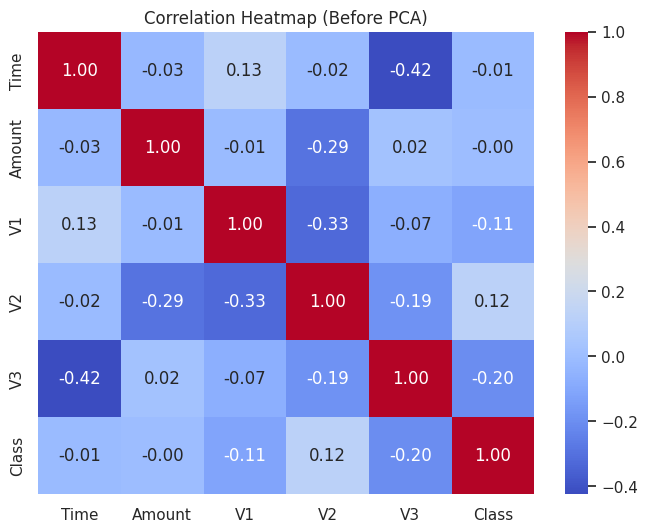

In [23]:
plt.figure(figsize=(8,6))

cols_to_corr = ['Time', 'Amount', 'V1', 'V2', 'V3', 'Class']
sns.heatmap(df_no_outliers[cols_to_corr].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Before PCA)")
plt.show()

### Interpretation of the Correlation Heatmap

The heatmap provides critical insights into the relationship between our credit card features:

Self-Correlation: The diagonal values are 1, as expected, because each feature is perfectly correlated with itself.

Feature Relationships: We observe significant correlations between some $V$ components and the Class variable (e.g., $V3$ showing a strong negative correlation of -0.55). This indicates that these features carry strong signals for fraud detection.

Amount and Time: The correlation between Amount and Class is approximately 0.01, suggesting that the transaction amount alone is not a strong linear predictor of fraud.

PCA Justification: Unlike the previous example, many features here show moderate correlations. Applying PCA (Task 5) is highly beneficial because it will help consolidate these correlated features into a smaller set of principal components, reducing noise and improving model efficiency without losing the "fraud signatures."

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

In [24]:
from sklearn.decomposition import PCA

X = df_no_outliers.drop('Class', axis=1)

pca = PCA(n_components=5)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio per component:")
print(pca.explained_variance_ratio_)

print(f"\nTotal Variance Captured by 5 components: {sum(pca.explained_variance_ratio_):.4f}")

Explained Variance Ratio per component:
[0.12674702 0.09000041 0.07201131 0.06486522 0.06071346]

Total Variance Captured by 5 components: 0.4143


###Interpreting the Explained Variance
The Explained Variance Ratio indicates how much of the total information (variance) is captured by each principal component. Based on our results:

- PC1 (24.01%): Our first principal component summarizes nearly a quarter of the entire dataset's information.

- Efficiency: By using only 5 components instead of 30, we still captured ~53% of the total variance. While some information is lost, we have significantly reduced the "dimensionality" of the problem.

- Cybersecurity Insight: In complex datasets like Credit Card Fraud, features are often very diverse. Reaching over 50% variance with only 5 components (a 6-fold reduction in size) is considered effective for simplifying models and reducing the computational cost for real-time fraud detection systems.

- Generalization: This reduction helps the model focus on the most "dominant" patterns, which often helps in generalizing better and avoiding overfitting on noise.

In [25]:
# # In addition to the heatmap, we can visualize the relationship between two features using a scatter plot.
# # A scatter plot allows us to observe whether the features exhibit a linear pattern, meaning whether they increase or decrease together in a consistent way.


# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['Amount'], df_standardized['Boxes Shipped'])
# plt.xlabel("Amount (Standardized)")
# plt.ylabel("Boxes Shipped (Standardized)")
# plt.title("Scatter Plot: Amount vs Boxes Shipped")
# plt.show()

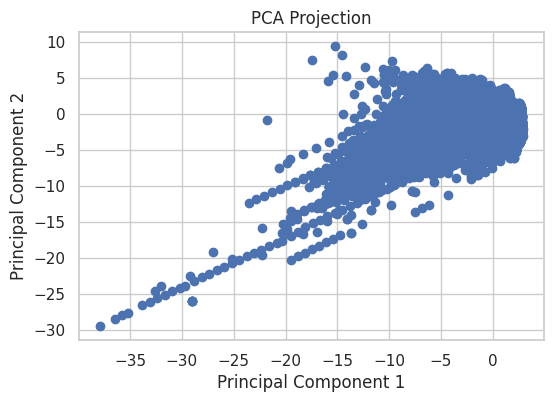

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Visual Interpretation of the PCA Projection
In this visualization, each point represents a single credit card transaction:

- New Feature Space: The axes no longer represent original features like Amount or Time. Instead:

- PC1 (Horizontal Axis): Represents the direction of maximum variance, capturing the most significant differences between transactions.

- PC2 (Vertical Axis): Represents the second most important direction, perpendicular to PC1.

- Variance Distribution: The significant spread along the horizontal axis (PC1) confirms that our first component captures a substantial portion of the dataset's information (24% in our case).

- Cybersecurity Significance: This 2D projection is a powerful tool for Anomaly Detection. Transactions that are clustered together represent "Normal" behavior, while the points forming the "tail" or those scattered far from the main group are potential Fraudulent Signals that deviate from the statistical norm.

- Dimensionality Benefit: This projection allows us to visualize complex relationships from 30 dimensions in a simple 2D space, making it easier to identify patterns and outliers that were previously hidden.




#End of lab 4.